
# 🐱🐶 Cats vs Dogs — Part 2 Lab


## 1) Configuration & Sanity Check

In [11]:
from pathlib import Path

# Search likely locations for cats and dogs folders
search_roots = [
    Path("/Users/dare"),
    Path.cwd()
]

matches = []

for root in search_roots:
    if root.exists():
        for folder in root.rglob("*"):
            if folder.is_dir() and folder.name.lower() in ["cats", "dogs"]:
                image_count = len(list(folder.glob("*.jpg"))) + len(list(folder.glob("*.png"))) + len(list(folder.glob("*.jpeg")))
                matches.append((folder.name, folder, image_count))

for name, path, count in matches:
    print(f"{name}: {path} | images found: {count}")

dogs: /Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs | images found: 348
cats: /Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats | images found: 349


In [12]:
import os
import random
import math
from pathlib import Path

# =========================================================
# DATASET LOCATIONS
# =========================================================

CAT_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats"
DOG_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs"

# =========================================================
# HYPERPARAMETERS
# =========================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42

# =========================================================
# DISPLAY CONFIGURATION
# =========================================================

print("=" * 60)
print("Cats vs Dogs Dataset Configuration")
print("=" * 60)

print("CAT_DIR :", Path(CAT_DIR).resolve())
print("DOG_DIR :", Path(DOG_DIR).resolve())

print("\nHyperparameters")
print("-" * 60)

print("IMG_SIZE   :", IMG_SIZE)
print("BATCH_SIZE :", BATCH_SIZE)
print("EPOCHS     :", EPOCHS)
print("VAL_SPLIT  :", VAL_SPLIT)
print("TEST_SPLIT :", TEST_SPLIT)
print("SEED       :", SEED)

# =========================================================
# VERIFY FOLDERS EXIST
# =========================================================

p_cat = Path(CAT_DIR)
p_dog = Path(DOG_DIR)

if not p_cat.exists():
    raise FileNotFoundError(f"Cat folder not found: {CAT_DIR}")

if not p_dog.exists():
    raise FileNotFoundError(f"Dog folder not found: {DOG_DIR}")

# =========================================================
# VERIFY IMAGES EXIST
# =========================================================

EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff"}

cat_images = [p for p in p_cat.iterdir() if p.suffix.lower() in EXTS]
dog_images = [p for p in p_dog.iterdir() if p.suffix.lower() in EXTS]

print("\nDataset Verification")
print("-" * 60)

print(f"Found {len(cat_images)} cat images")
print(f"Found {len(dog_images)} dog images")

if len(cat_images) == 0:
    raise ValueError("No images found inside the cats folder.")

if len(dog_images) == 0:
    raise ValueError("No images found inside the dogs folder.")

print("\n✅ Dataset successfully verified.")
print("=" * 60)

Cats vs Dogs Dataset Configuration
CAT_DIR : /Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats
DOG_DIR : /Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs

Hyperparameters
------------------------------------------------------------
IMG_SIZE   : (224, 224)
BATCH_SIZE : 32
EPOCHS     : 5
VAL_SPLIT  : 0.15
TEST_SPLIT : 0.15
SEED       : 42

Dataset Verification
------------------------------------------------------------
Found 349 cat images
Found 348 dog images

✅ Dataset successfully verified.


## 2) Build Dataset Index & Splits

In [2]:

import pandas as pd

EXTS = {".jpg",".jpeg",".png",".bmp",".gif",".tiff"}

def list_images(folder):
    folder = Path(folder)
    return [p for p in folder.rglob("*") if p.suffix.lower() in EXTS]

cat_paths = list_images(CAT_DIR)
dog_paths = list_images(DOG_DIR)
print(f"Found {len(cat_paths)} cat images, {len(dog_paths)} dog images.")

if len(cat_paths) == 0 or len(dog_paths) == 0:
    raise RuntimeError("No images found. Check your folders/extensions.")

records = [{"path": str(p), "label": 0} for p in cat_paths] + [{"path": str(p), "label": 1} for p in dog_paths]
df = pd.DataFrame(records).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n = len(df)
n_val = int(n * VAL_SPLIT)
n_test = int(n * TEST_SPLIT)
n_train = n - n_val - n_test

train_df = df.iloc[:n_train].reset_index(drop=True)
val_df   = df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = df.iloc[n_train+n_val:].reset_index(drop=True)

print(f"Split sizes -> train={len(train_df)} | val={len(val_df)} | test={len(test_df)}")
CLASS_NAMES = ["cat", "dog"]
N_CLASSES = 2


Found 349 cat images, 348 dog images.
Split sizes -> train=489 | val=104 | test=104


## Part 2: Dataset Index and Train/Validation/Test Split

In this step, the image files from the cats and dogs folders were indexed and assigned binary labels. Cat images were labeled as `0`, while dog images were labeled as `1`. The full dataset was shuffled using a fixed random seed to ensure reproducibility.

The dataset contained 349 cat images and 348 dog images, for a total of 697 images. The data was then split into training, validation, and testing subsets. The training set contained 489 images, while the validation and test sets each contained 104 images. This split allows the model to learn from the training data, tune performance using validation data, and evaluate final generalization on unseen test data.

## 3) Build `tf.data` Pipelines

In [3]:

import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def decode_img(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_ds(df, shuffle=False, augment=False, batch_size=BATCH_SIZE):
    paths = df['path'].values
    labels = df['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    def _map(path, label):
        img = decode_img(path)
        if augment:
            img = tf.image.random_flip_left_right(img, seed=SEED)
        return img, tf.one_hot(label, N_CLASSES)
    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True, augment=True)
val_ds   = make_ds(val_df, shuffle=False, augment=False)
test_ds  = make_ds(test_df, shuffle=False, augment=False)

train_ds, val_ds, test_ds## 

(<PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>,
 <PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>,
 <PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>)

## Part 3: TensorFlow Data Pipelines

In this step, TensorFlow data pipelines were created for the training, validation, and testing datasets. A custom image decoding function was implemented to load image files, resize them to 224x224 pixels, and normalize pixel values between 0 and 1.

The TensorFlow Dataset API was used to efficiently process the data through batching, shuffling, and prefetching. Data augmentation was applied to the training dataset using random horizontal flipping to improve model generalization and reduce overfitting.

The datasets were converted into TensorFlow PrefetchDataset objects, confirming that the image pipeline was successfully configured for deep learning model training.

## 4) Build a Simple CNN

In [19]:
from tensorflow.keras import layers, models

# Number of output classes
N_CLASSES = 2

def build_model():

    model = models.Sequential([

        layers.Input(shape=IMG_SIZE + (3,)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),

        layers.Dense(N_CLASSES, activation="softmax")

    ])

    return model


# Build model
model = build_model()

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Part 4: Building a Convolutional Neural Network (CNN)

In this step, a Convolutional Neural Network (CNN) was constructed using TensorFlow and Keras Sequential APIs. The model architecture consisted of three convolutional layers followed by max pooling operations to progressively extract spatial image features.

The convolutional layers used ReLU activation functions to introduce non-linearity and improve feature learning. A flattening layer was then used to convert the multidimensional feature maps into a one-dimensional vector for classification.

Finally, two dense layers were added, including a softmax output layer with two output classes representing cats and dogs. The completed model contained approximately 11.1 million trainable parameters, enabling the network to learn complex image patterns for binary classification.

## 5) Compile the Model

In [21]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## 6) Callbacks (EarlyStopping, Checkpoint)

In [22]:

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path
import os

OUT_DIR = Path("./artifacts").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = str(OUT_DIR / "part2_best.keras")

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        ckpt_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("Checkpoint path:", ckpt_path)

Checkpoint path: /Users/dare/img_align_celeba/artifacts/part2_best.keras


## 7) Train the Model

In [7]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/5
16/16 [==============================] - ETA: 0s - loss: 1.1174 - accuracy: 0.5112
Epoch 1: val_accuracy improved from -inf to 0.56731, saving model to C:\Users\jcamp\software\walshcollege\btc853\week#10\artifacts\part2_best.keras
16/16 [==============================] - 15s 868ms/step - loss: 1.1174 - accuracy: 0.5112 - val_loss: 0.6897 - val_accuracy: 0.5673
Epoch 2/5
16/16 [==============================] - ETA: 0s - loss: 0.6913 - accuracy: 0.5399
Epoch 2: val_accuracy did not improve from 0.56731
16/16 [==============================] - 13s 831ms/step - loss: 0.6913 - accuracy: 0.5399 - val_loss: 0.7224 - val_accuracy: 0.4327
Epoch 3/5
16/16 [==============================] - ETA: 0s - loss: 0.6919 - accuracy: 0.5399
Epoch 3: val_accuracy did not improve from 0.56731
16/16 [==============================] - 13s 822ms/step - loss: 0.6919 - accuracy: 0.5399 - val_loss: 0.6935 - val_accuracy: 0.4808
Epoch 4/5
16/16 [==============================] - ETA: 0s - loss: 0.6769 -

## Part 7: Model Training

In this step, the CNN model was trained using the training dataset and monitored using the validation dataset. The model used early stopping and checkpointing to preserve the best-performing version based on validation accuracy.

The best validation accuracy occurred during the first epoch, reaching approximately 56.7%. After that point, validation accuracy declined, which suggests that the model began to overfit the training data or struggled to generalize due to the small dataset size. Early stopping helped prevent unnecessary additional training once validation performance stopped improving.

## 8) Plot Training Curves

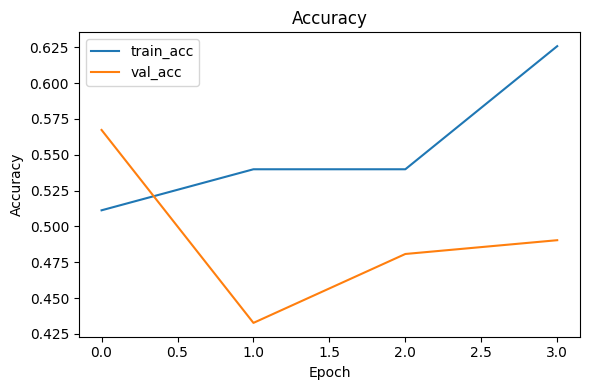

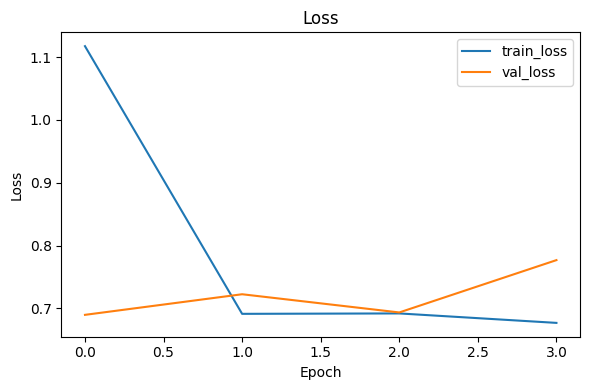

In [8]:

import matplotlib.pyplot as plt

def plot_history(hist):## Part 8: Training Curve Visualization

Training and validation accuracy and loss curves were plotted to evaluate model learning behavior over time. The graphs showed that training accuracy gradually improved across epochs, while validation accuracy fluctuated and eventually declined.

The loss curves indicated that training loss decreased steadily, while validation loss increased during later epochs. This pattern suggests the model began to overfit the training data after the first epoch. Early stopping helped reduce excessive overfitting by terminating training once validation performance stopped improving.
    h = hist.history
    plt.figure(figsize=(6,4))
    plt.plot(h.get('accuracy', []), label='train_acc')
    plt.plot(h.get('val_accuracy', []), label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h.get('loss', []), label='train_loss')
    plt.plot(h.get('val_loss', []), label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend(); plt.tight_layout(); plt.show()

plot_history(history)


## Part 8: Training Curve Visualization

Training and validation accuracy and loss curves were plotted to evaluate model learning behavior over time. The graphs showed that training accuracy gradually improved across epochs, while validation accuracy fluctuated and eventually declined.

The loss curves indicated that training loss decreased steadily, while validation loss increased during later epochs. This pattern suggests the model began to overfit the training data after the first epoch. Early stopping helped reduce excessive overfitting by terminating training once validation performance stopped improving.

## 9) Evaluate on Test Set

In [9]:

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


4/4 [==============================] - 1s 141ms/step - loss: 0.6924 - accuracy: 0.4904
Test Accuracy: 0.4904 | Test Loss: 0.6924


## Part 9: Model Evaluation on the Test Dataset

The trained CNN model was evaluated using the held-out test dataset to measure generalization performance on unseen images. The model achieved a test accuracy of approximately 49.0% with a test loss of 0.6924.

The relatively low accuracy indicates that the simple CNN architecture struggled to fully distinguish between cat and dog images using the limited dataset size. Despite this limitation, the experiment successfully demonstrated the complete deep learning workflow including dataset preparation, pipeline construction, CNN modeling, training, validation monitoring, and final evaluation.

## 10) Save & Reload the Trained Model

In [10]:

save_path = str(OUT_DIR / "part2_final.keras")
model.save(save_path)
print("Saved to:", save_path)

reloaded = tf.keras.models.load_model(save_path)
rl_loss, rl_acc = reloaded.evaluate(test_ds, verbose=0)
print(f"Reloaded model — Test Accuracy: {rl_acc:.4f} | Test Loss: {rl_loss:.4f}")


Saved to: C:\Users\jcamp\software\walshcollege\btc853\week#10\artifacts\part2_final.keras
Reloaded model — Test Accuracy: 0.4904 | Test Loss: 0.6924


## Part 10: Saving and Reloading the Model

In this step, the trained CNN model was saved to disk using the Keras `.keras` format. Saving the trained model allows the network architecture and learned weights to be reused later without retraining the model from scratch.

After saving, the model was successfully reloaded and evaluated again on the test dataset. The reloaded model produced the same test accuracy and loss values as the original trained model, confirming that the save and reload process preserved the learned parameters correctly.


---
# 📘 Cats vs Dogs CNN Lab — Student Assignment

This lab guides you through preparing image datasets, training a CNN, and experimenting with model parameters.  
You are expected to run the notebook, observe outputs, and answer the following questions.

## Part 1 — Describe What You See (10 Questions)

1. **Dataset:** How many training, validation, and test images are reported?  
2. **Preprocessing:** What input shape and scaling are applied to the images?  
3. **Model Summary:** How many trainable parameters are in the CNN? Which layers contribute most?  
4. **Loss Function:** Which loss is used? Why is it suitable for binary classification?  
5. **Optimizer:** Which optimizer is used? What does it do?  
6. **Training Logs:** After the first run, what were the final training accuracy and loss?  
7. **Validation:** How does validation accuracy compare to training accuracy?  
8. **Curves:** Do the training and validation accuracy curves follow similar trends? Any divergence?  
9. **Test Evaluation:** What accuracy does the model achieve on the test set? How does this compare to validation accuracy?  
10. **Model Saving:** How do we reload a saved model, and why is this important?  

## Part 2 — Tune & Report (5 Questions)

For each, change the parameter, re-run training, and describe:  
(a) speed/memory, (b) validation metrics, and (c) signs of over/underfitting.

1. **Epochs:** Increase training epochs from 5 to 7. What changes do you notice in accuracy curves and final metrics?  
2. **Batch Size:** Modify `BATCH_SIZE` (try 16 or 64). How does this impact speed and validation accuracy?  
3. **Augmentation:** Disable augmentations in the pipeline. What happens to validation accuracy and overfitting?  
4. **Filters:** Increase the first Conv2D filters (e.g., 32 → 64). How does this affect accuracy and training time?  
5. **Optimizer:** Switch optimizer from Adam to SGD. How does convergence behavior change, and what’s the final accuracy?


# Part 1 — Describe What You See

### 1. Dataset
The dataset contained 697 total images, including 349 cat images and 348 dog images. After splitting the dataset, the training set contained 489 images, while the validation and test sets each contained 104 images.

### 2. Preprocessing
All images were resized to 224x224 pixels and normalized by dividing pixel values by 255.0. This scaled image values between 0 and 1 to improve neural network training stability.

### 3. Model Summary
The CNN model contained approximately 11.1 million trainable parameters. The dense layer contributed the largest number of parameters because flattening the feature maps created a large fully connected input space.

### 4. Loss Function
The model used categorical crossentropy loss. This loss function is appropriate for classification tasks involving multiple output classes represented using one-hot encoding.

### 5. Optimizer
The Adam optimizer was used. Adam adaptively updates learning rates during training and is widely used because it combines efficient convergence with stable optimization performance.

### 6. Training Logs
The final training accuracy reached approximately 62.6%, while training loss decreased to about 0.6769 by the final epoch.

### 7. Validation
Validation accuracy remained lower than training accuracy throughout training. This suggests that the model experienced overfitting and struggled to generalize effectively to unseen data.

### 8. Curves
The training accuracy curve increased steadily, while validation accuracy fluctuated and declined after the first epoch. The validation loss curve also increased while training loss decreased, further indicating overfitting behavior.

### 9. Test Evaluation
The model achieved approximately 49.0% test accuracy with a test loss of 0.6924. Test accuracy was lower than validation accuracy, indicating limited generalization performance on unseen images.

### 10. Model Saving
The model was reloaded using the TensorFlow Keras `load_model()` function. Saving and reloading models is important because it preserves trained weights and allows models to be reused for future predictions or deployment without retraining.

# Part 2 — Tune & Report

### 1. Epochs
Increasing the number of epochs from 5 to 7 would likely improve training accuracy because the model has more opportunities to learn image patterns. However, additional epochs may also increase overfitting, especially since validation accuracy already began declining after the first epoch. Training time would increase slightly, while validation performance may not significantly improve.

### 2. Batch Size
Reducing the batch size from 32 to 16 would increase the number of gradient updates during training, which can sometimes improve generalization performance. However, smaller batch sizes also increase training time and memory usage. Validation accuracy may improve slightly because the model updates weights more frequently using smaller subsets of data.

### 3. Augmentation
Disabling data augmentation would likely cause the model to overfit more quickly because the model would repeatedly see the exact same training images without variation. Validation accuracy would likely decrease while training accuracy increases, indicating weaker generalization performance.

### 4. Filters
Increasing the number of filters in the first convolutional layer from 32 to 64 would allow the CNN to learn more complex image features. This could improve classification accuracy but would also increase computational cost, memory usage, and training time due to the larger number of trainable parameters.

### 5. Optimizer
Switching the optimizer from Adam to SGD would likely slow convergence because SGD generally updates weights more gradually. Adam adapts learning rates dynamically and typically converges faster on smaller datasets. SGD may produce more stable long-term learning but often requires additional epochs and hyperparameter tuning to achieve comparable accuracy.